# 70 — Performance Dashboard

One-stop diagnostic notebook generated by
`scripts/build_performance_dashboard_notebook.py`.

Loads `metrics.json` + `predictions.csv` from every relevant model artifact
and renders side-by-side tables and plots so you can quickly verify the
performance of the current deployed model, all 3-DS variants, the
single-family pooled retrain (task b), and the LODO folds.


In [1]:
# --- Setup ---
%matplotlib inline
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

_root = Path.cwd()
if _root.name == 'notebooks':
    _root = _root.parent
    os.chdir(_root)
sys.path.insert(0, str(_root))

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

ART = _root / 'artifacts'
print('Project root:', _root)
print('Artifacts:   ', ART)


Project root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Artifacts:    C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts


## 1. Variants under inspection

In [2]:
VARIANTS = {
    'PROD (current ensemble dir)':
        ART / 'balanced_bagging_firewall_tuned_ensemble',
    '2-DS backup (ISCX+VNAT)':
        ART / 'balanced_bagging_firewall_tuned_ensemble_2dataset_backup',
    '3-DS REFRESH (new, this run)':
        ART / 'balanced_bagging_firewall_tuned_ensemble_3dataset_REFRESH',
    '3-DS DEGRADED (older snapshot)':
        ART / 'balanced_bagging_firewall_tuned_ensemble_3dataset_DEGRADED',
}
SINGLE_POOLED = ART / 'clean_pipeline' / 'models_3ds_66k'   # task b output
LODO_DIR = ART / 'lood_firewall_tuned'

def _exists(d): return d.exists() and (d / 'predictions.csv').exists()
for name, d in VARIANTS.items():
    print(f'  {name:42s} {"OK" if _exists(d) else "missing"}   {d.relative_to(_root)}')
print(f'  {"SINGLE pooled retrain":42s} {"OK" if _exists(SINGLE_POOLED) else "missing"}   {SINGLE_POOLED.relative_to(_root) if SINGLE_POOLED.exists() else SINGLE_POOLED}')
print(f'  {"LODO summary":42s} {"OK" if (LODO_DIR/"lodo_summary.json").exists() else "missing"}   {LODO_DIR.relative_to(_root)}')


  PROD (current ensemble dir)                OK   artifacts\balanced_bagging_firewall_tuned_ensemble
  2-DS backup (ISCX+VNAT)                    OK   artifacts\balanced_bagging_firewall_tuned_ensemble_2dataset_backup
  3-DS REFRESH (new, this run)               OK   artifacts\balanced_bagging_firewall_tuned_ensemble_3dataset_REFRESH
  3-DS DEGRADED (older snapshot)             OK   artifacts\balanced_bagging_firewall_tuned_ensemble_3dataset_DEGRADED
  SINGLE pooled retrain                      OK   artifacts\clean_pipeline\models_3ds_66k
  LODO summary                               OK   artifacts\lood_firewall_tuned


## 2. Flow-level AUC / PR-AUC comparison across variants

In [3]:
def load_preds(path):
    return pd.read_csv(path / 'predictions.csv')

rows = []
for name, d in VARIANTS.items():
    if not _exists(d): continue
    df = load_preds(d)
    for split in ('val', 'test'):
        sub = df[df['split'] == split]
        if len(sub) == 0: continue
        for col, label in [('prob_raw','raw'), ('prob_iso','iso'), ('prob_platt','platt')]:
            if col not in sub.columns: continue
            rows.append({
                'variant': name, 'split': split, 'calibration': label,
                'n': len(sub), 'n_vpn': int(sub['label'].sum()),
                'AUC': roc_auc_score(sub['label'], sub[col]),
                'PR-AUC': average_precision_score(sub['label'], sub[col]),
            })
auc_df = pd.DataFrame(rows)
print('Flow-level AUC / PR-AUC summary:')
display(auc_df.pivot_table(index=['variant','calibration'], columns='split',
                           values=['AUC','PR-AUC']).round(4))


Flow-level AUC / PR-AUC summary:


AUC          PR-AUC        
split                                         test     val    test     val
variant                        calibration                                
2-DS backup (ISCX+VNAT)        iso          0.9461  0.9846  0.8496  0.9754
                               platt        0.9443  0.9817  0.8613  0.9773
                               raw          0.9443  0.9817  0.8613  0.9773
3-DS DEGRADED (older snapshot) iso          0.9825  0.9753  0.8513  0.7381
                               platt        0.9862  0.9688  0.8933  0.7521
                               raw          0.9862  0.9688  0.8933  0.7521
3-DS REFRESH (new, this run)   iso          0.9825  0.9753  0.8513  0.7381
                               platt        0.9862  0.9688  0.8933  0.7521
                               raw          0.9862  0.9688  0.8933  0.7521
PROD (current ensemble dir)    iso          0.9825  0.9753  0.8513  0.7381
                               platt        0.9862  0.9688  0.8933  0.7521
                               raw          0.9862  0.9688  0.8933  0.7521

## 3. ROC and PR curves — test set, isotonic calibration

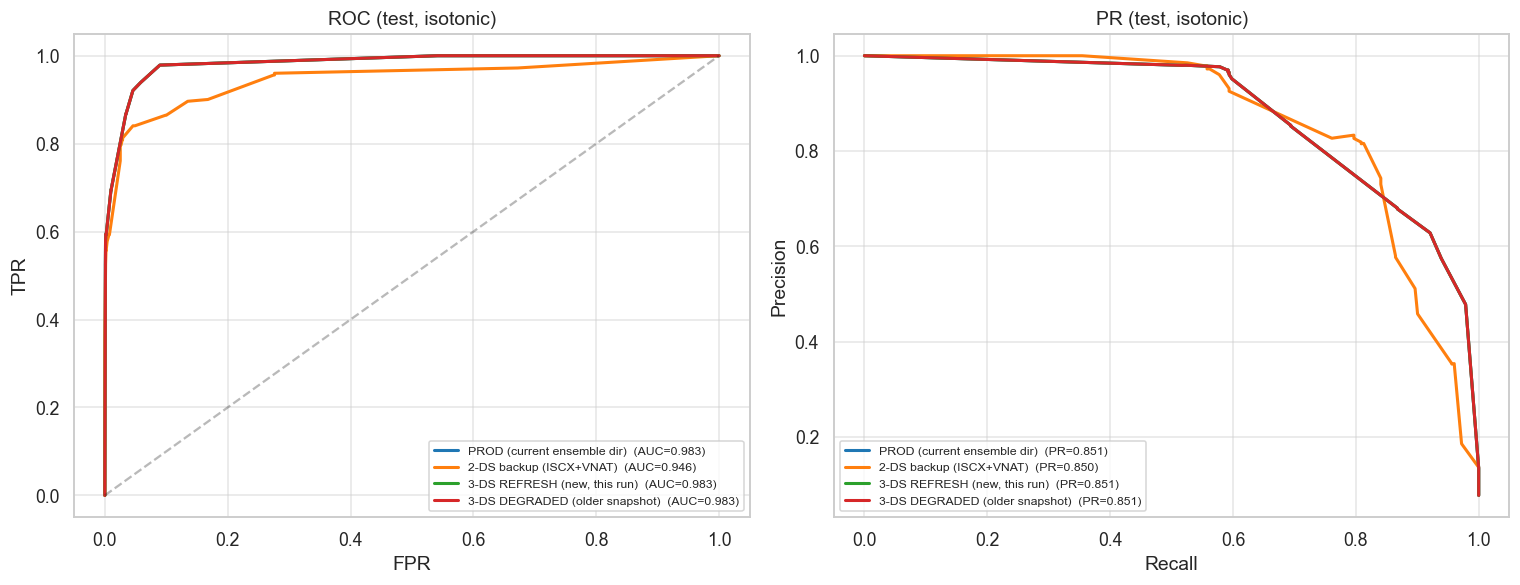

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.tab10.colors
for i, (name, d) in enumerate(VARIANTS.items()):
    if not _exists(d): continue
    df = load_preds(d)
    test = df[df['split']=='test']
    if len(test)==0 or 'prob_iso' not in test.columns: continue
    y, p = test['label'].values, test['prob_iso'].values
    fpr, tpr, _ = roc_curve(y, p); auc = roc_auc_score(y, p)
    prec, rec, _ = precision_recall_curve(y, p); pr = average_precision_score(y, p)
    axes[0].plot(fpr, tpr, color=colors[i%10], lw=2,
                 label=f'{name}  (AUC={auc:.3f})')
    axes[1].plot(rec, prec, color=colors[i%10], lw=2,
                 label=f'{name}  (PR={pr:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=.3); axes[0].set_title('ROC (test, isotonic)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8, loc='lower right')
axes[1].set_title('PR (test, isotonic)'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()


## 4. Per-dataset AUC on test (isotonic)

dataset,iscx,usbvpn,vnat
variant,,,
2-DS backup (ISCX+VNAT),0.9427,NaN,0.9973
3-DS DEGRADED (older snapshot),0.8490,0.9917,0.9505
"3-DS REFRESH (new, this run)",0.8490,0.9917,0.9505
PROD (current ensemble dir),0.8490,0.9917,0.9505


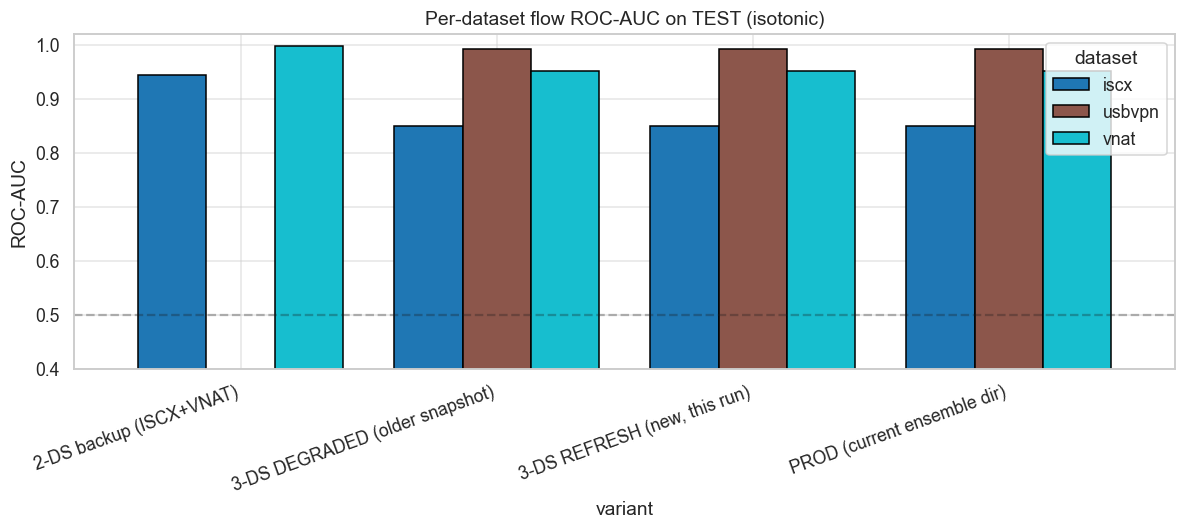

In [5]:
rows = []
for name, d in VARIANTS.items():
    if not _exists(d): continue
    df = load_preds(d)
    test = df[df['split']=='test']
    if len(test)==0 or 'prob_iso' not in test.columns: continue
    for ds in sorted(test['dataset'].unique()):
        sub = test[test['dataset']==ds]
        if sub['label'].nunique() < 2:
            rows.append({'variant':name,'dataset':ds,'AUC':np.nan,'n':len(sub),'n_vpn':int(sub['label'].sum())})
            continue
        rows.append({'variant':name,'dataset':ds,
                     'AUC':roc_auc_score(sub['label'], sub['prob_iso']),
                     'n':len(sub),'n_vpn':int(sub['label'].sum())})
ds_df = pd.DataFrame(rows)
pivot_auc = ds_df.pivot(index='variant', columns='dataset', values='AUC').round(4)
display(pivot_auc)

fig, ax = plt.subplots(figsize=(11, 5))
pivot_auc.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', width=0.8)
ax.set_title('Per-dataset flow ROC-AUC on TEST (isotonic)')
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.4, 1.02)
ax.axhline(0.5, color='k', linestyle='--', alpha=0.3)
ax.legend(title='dataset'); ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()


## 5. Session-level metrics — block recall @ zero FPR, per dataset

In [6]:
from src.eval.session_metrics import aggregate_to_session
from src.deployment.decision_engine import AGGREGATORS

def session_table(d, prob_col='prob_iso', agg='wt5'):
    df = load_preds(d)
    test = df[df['split']=='test']
    if len(test) == 0 or prob_col not in test.columns: return None
    out = []
    for ds in ['__pooled__'] + sorted(test['dataset'].unique().tolist()):
        sub = test if ds == '__pooled__' else test[test['dataset']==ds]
        if len(sub) == 0: continue
        fn = AGGREGATORS[agg]
        g = sub.groupby('capture_id')
        s = g[prob_col].apply(lambda x: fn(np.asarray(x, dtype=float))).reset_index()
        y = g['label'].max().reset_index()
        sess = s.merge(y, on='capture_id')
        if sess['label'].nunique() < 2:
            out.append({'dataset':ds,'session_auc':np.nan,'block_recall@0FPR':np.nan,
                        'n_sessions':len(sess),'n_vpn_sessions':int(sess['label'].sum())})
            continue
        auc = roc_auc_score(sess['label'], sess[prob_col])
        # block_recall @ zero FPR
        benign_max = sess.loc[sess['label']==0, prob_col].max()
        thr = np.nextafter(benign_max, np.inf)
        rec = ((sess['label']==1) & (sess[prob_col]>=thr)).sum() / max(int((sess['label']==1).sum()), 1)
        out.append({'dataset':ds,'session_auc':round(auc,4),
                    'block_recall@0FPR':round(rec,4),
                    'n_sessions':len(sess),'n_vpn_sessions':int(sess['label'].sum())})
    return pd.DataFrame(out)

for name, d in VARIANTS.items():
    if not _exists(d): continue
    print(f'\n=== {name}  (wt5 + prob_iso) ===')
    t = session_table(d)
    if t is not None: display(t)



=== PROD (current ensemble dir)  (wt5 + prob_iso) ===


,dataset,session_auc,block_recall@0FPR,n_sessions,n_vpn_sessions
0,__pooled__,0.9218,0.4,106,5
1,iscx,0.6912,0.0,19,2
2,usbvpn,1.0000,1.0,74,2
3,vnat,0.6667,0.0,13,1



=== 2-DS backup (ISCX+VNAT)  (wt5 + prob_iso) ===


,dataset,session_auc,block_recall@0FPR,n_sessions,n_vpn_sessions
0,__pooled__,0.9686,0.7059,47,17
1,iscx,1.0000,1.0000,21,4
2,vnat,1.0000,1.0000,26,13



=== 3-DS REFRESH (new, this run)  (wt5 + prob_iso) ===


,dataset,session_auc,block_recall@0FPR,n_sessions,n_vpn_sessions
0,__pooled__,0.9218,0.4,106,5
1,iscx,0.6912,0.0,19,2
2,usbvpn,1.0000,1.0,74,2
3,vnat,0.6667,0.0,13,1



=== 3-DS DEGRADED (older snapshot)  (wt5 + prob_iso) ===


,dataset,session_auc,block_recall@0FPR,n_sessions,n_vpn_sessions
0,__pooled__,0.9218,0.4,106,5
1,iscx,0.6912,0.0,19,2
2,usbvpn,1.0000,1.0,74,2
3,vnat,0.6667,0.0,13,1


## 6. Calibration curves — isotonic on test

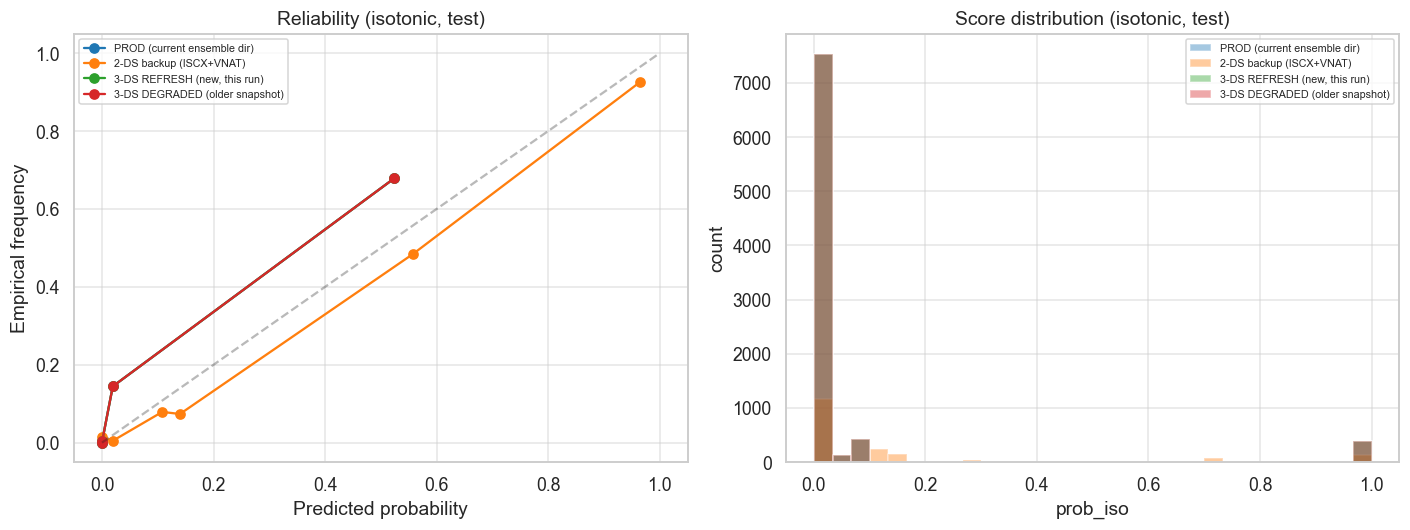

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (name, d) in enumerate(VARIANTS.items()):
    if not _exists(d): continue
    df = load_preds(d)
    test = df[df['split']=='test']
    if len(test)==0 or 'prob_iso' not in test.columns: continue
    prob_true, prob_pred = calibration_curve(test['label'], test['prob_iso'], n_bins=10, strategy='quantile')
    axes[0].plot(prob_pred, prob_true, 'o-', color=plt.cm.tab10.colors[i%10], label=name)
    axes[1].hist(test['prob_iso'], bins=30, alpha=0.4, color=plt.cm.tab10.colors[i%10], label=name)
axes[0].plot([0,1],[0,1],'k--',alpha=.3); axes[0].set_title('Reliability (isotonic, test)')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Empirical frequency'); axes[0].legend(fontsize=7)
axes[1].set_title('Score distribution (isotonic, test)'); axes[1].set_xlabel('prob_iso'); axes[1].set_ylabel('count')
axes[1].legend(fontsize=7); plt.tight_layout(); plt.show()


## 7. LODO summary — held-out generalisation

LODO summary table:


,holdout,calibration,val_auc,holdout_AUC,holdout_PR-AUC,holdout_sess_AUC,holdout_block_rec@0
0,iscx,raw,0.9994,0.4116,0.2060,0.5135,NaN
1,iscx,isotonic,0.9996,0.4645,0.2376,0.5155,NaN
2,iscx,platt,0.9994,0.4116,0.2060,0.4978,NaN
3,usbvpn,raw,0.3188,0.2595,0.1433,0.7770,0.4348
4,usbvpn,isotonic,0.5608,0.3655,0.1341,0.6918,0.6957
5,usbvpn,platt,0.6812,0.7405,0.4071,0.8134,0.0435
6,vnat,raw,0.9824,0.4997,0.0045,0.1229,NaN
7,vnat,isotonic,0.9865,0.4764,0.0041,0.1000,NaN
8,vnat,platt,0.9824,0.4997,0.0045,0.1012,NaN


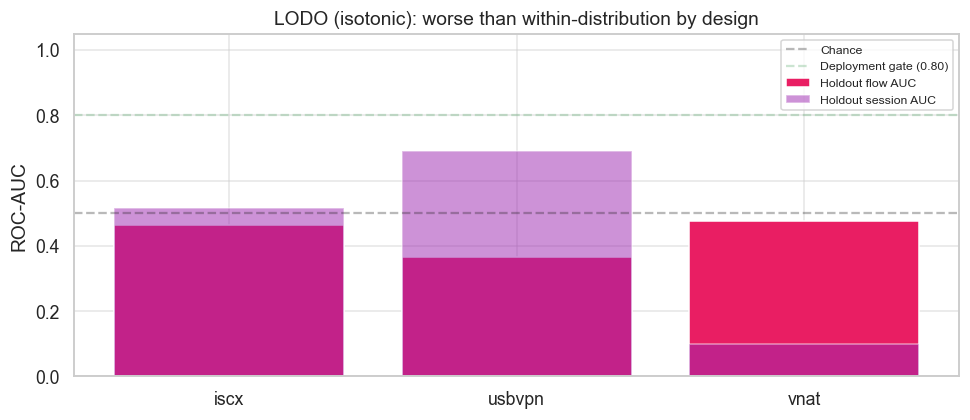

In [8]:
lodo_path = LODO_DIR / 'lodo_summary.json'
if lodo_path.exists():
    lodo = json.loads(lodo_path.read_text())
    lodo_rows = []
    for entry in lodo:
        for cal in ('raw', 'isotonic', 'platt'):
            blk = entry[cal]
            lodo_rows.append({
                'holdout': entry['holdout'], 'calibration': cal,
                'val_auc':           round(blk['val_auc'], 4) if blk['val_auc'] else None,
                'holdout_AUC':       round(blk['holdout_auc'], 4) if blk['holdout_auc'] else None,
                'holdout_PR-AUC':    round(blk['holdout_pr_auc'], 4) if blk['holdout_pr_auc'] else None,
                'holdout_sess_AUC':  round(blk['holdout_session_roc_auc'], 4) if blk['holdout_session_roc_auc'] else None,
                'holdout_block_rec@0': round(blk['holdout_block_recall_at_zero_fp'], 4) if blk['holdout_block_recall_at_zero_fp'] else None,
            })
    lodo_df = pd.DataFrame(lodo_rows)
    print('LODO summary table:')
    display(lodo_df)

    fig, ax = plt.subplots(figsize=(9, 4))
    sub = lodo_df[lodo_df['calibration']=='isotonic']
    ax.bar(sub['holdout'], sub['holdout_AUC'], color='#E91E63', label='Holdout flow AUC')
    ax.bar(sub['holdout'], sub['holdout_sess_AUC'], color='#9C27B0', alpha=0.5, label='Holdout session AUC')
    ax.axhline(0.5, color='k', linestyle='--', alpha=0.3, label='Chance')
    ax.axhline(0.8, color='g', linestyle='--', alpha=0.3, label='Deployment gate (0.80)')
    ax.set_title('LODO (isotonic): worse than within-distribution by design')
    ax.set_ylabel('ROC-AUC'); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('lodo_summary.json missing — run scripts/train_3dataset_and_lodo.py first.')


## 8. Single-family pooled retrain (task b output)

In [9]:
if SINGLE_POOLED.exists():
    rep = json.loads((SINGLE_POOLED / 'evaluation_report.json').read_text())
    print('Global metrics (single-family models retrained on pooled 66K flows):')
    display(pd.DataFrame(rep['global']).T)
    if rep.get('per_dataset'):
        print('\nPer-dataset metrics on test:')
        # flatten per-dataset
        rows = []
        for ds, blk in rep['per_dataset'].items():
            if 'note' in blk:
                rows.append({'dataset':ds,'note':blk['note']}); continue
            r = {'dataset':ds,'n_flows':blk['n_flows'],'n_vpn':blk['n_vpn']}
            for fam in ('xgb','lgb','cb','ensemble_mean'):
                r[f'{fam}_AUC'] = round(blk[fam]['auc'],4)
                r[f'{fam}_PR']  = round(blk[fam]['pr_auc'],4)
            rows.append(r)
        display(pd.DataFrame(rows))
else:
    print('SINGLE_POOLED missing — run scripts/train_clean_pipeline_singles_pooled.py first.')


Global metrics (single-family models retrained on pooled 66K flows):


,val,test
xgb,"{'auc': 0.9804540160515003, 'pr_auc': 0.741284...","{'auc': 0.9855098468492296, 'pr_auc': 0.869460..."
lgb,"{'auc': 0.9536893039408761, 'pr_auc': 0.540571...","{'auc': 0.9440969394314006, 'pr_auc': 0.647394..."
cb,"{'auc': 0.9745441839781462, 'pr_auc': 0.751741...","{'auc': 0.9850153391567367, 'pr_auc': 0.875855..."
ensemble_mean,"{'auc': 0.9809660546767465, 'pr_auc': 0.789872...","{'auc': 0.9849595092091256, 'pr_auc': 0.882101..."



Per-dataset metrics on test:


,dataset,n_flows,n_vpn,xgb_AUC,xgb_PR,lgb_AUC,lgb_PR,cb_AUC,cb_PR,ensemble_mean_AUC,ensemble_mean_PR
0,iscx,1278,231,0.8502,0.4340,0.4621,0.1789,0.8231,0.3961,0.8400,0.4194
1,usbvpn,6810,423,0.9967,0.9730,0.9832,0.8305,0.9979,0.9775,0.9959,0.9725
2,vnat,407,3,0.9942,0.4667,0.8577,0.0254,0.9876,0.3547,0.9950,0.4778


## 9. Deployment recommendation snapshot

In [10]:
for fname in ('deployment_recommendation_3DS.json', 'deployment_recommendation.json'):
    p = ART / 'deployment' / 'final' / fname
    if p.exists():
        print(f'\n=== {fname} ===')
        rec = json.loads(p.read_text())
        # print only the headline keys to keep output short
        for k in ('model','thresholds','pooled_test','deployment_modes','recommended_production_policy'):
            if k in rec:
                print(f'\n-- {k} --')
                print(json.dumps(rec[k], indent=2, default=str)[:1600])



=== deployment_recommendation_3DS.json ===

-- model --
{
  "name": "3DS-Balanced Ensemble (refreshed)",
  "train_datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_train_flows": 49506,
  "model_types": [
    "xgb",
    "lgbm",
    "catboost"
  ]
}

-- thresholds --
{
  "strict_block": 0.8776583661351073,
  "balanced_block": 0.08860759493670882,
  "conservative_raw": 0.8776583661351073
}

-- pooled_test --
{
  "strict_block": {
    "recall": 0.2,
    "fpr": 0.0,
    "tp": 1,
    "fp": 0,
    "tn": 101,
    "fn": 4,
    "n_sessions": 106,
    "n_vpn": 5
  },
  "balanced_block": {
    "recall": 0.4,
    "fpr": 0.0297029702970297,
    "tp": 2,
    "fp": 3,
    "tn": 98,
    "fn": 3,
    "n_sessions": 106,
    "n_vpn": 5
  }
}

=== deployment_recommendation.json ===

-- model --
{
  "name": "3DS-Balanced-5f Ensemble",
  "features": [
    "sz_coef_variation",
    "sz_p25_median_ratio",
    "sz_p75_median_ratio",
    "sz_iqr_norm_median",
    "dispersion_symmetry"
  ],
  "model_typ

---\n_End of dashboard._